# BEV Segmentation Pipeline Verification

This notebook verifies the Stage 1 BEV segmentation submodule for the high-altitude UAV.
It checks the Grounded-SAM2 environment, validates noun extraction, runs single-frame segmentation,
and executes a small batch pass that produces the summary fields needed by the later graph pipeline.


In [1]:
from pathlib import Path
import json
import os
import sys


def find_workspace_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        probe = candidate / "aeroduo" / "pilot_llm" / "high_uav" / "bev_segmentation.py"
        if probe.exists():
            return candidate
    raise FileNotFoundError("Could not locate the aeroduo workspace root from the current notebook cwd.")


WORKSPACE_ROOT = find_workspace_root(Path.cwd().resolve())
PILOT_LLM_DIR = WORKSPACE_ROOT / "aeroduo" / "pilot_llm"
HIGH_UAV_DIR = PILOT_LLM_DIR / "high_uav"
GROUNDED_SAM2_DIR = PILOT_LLM_DIR / "Grounded-SAM-2"
ENV_PYTHON = Path("/storage/project/r-cj124-0/sibidapo3/anxcnda/aeroduo/bin/python")

RUNTIME_CACHE = WORKSPACE_ROOT / ".cache"
(RUNTIME_CACHE / "matplotlib").mkdir(parents=True, exist_ok=True)
os.environ["MPLCONFIGDIR"] = str(RUNTIME_CACHE / "matplotlib")
os.environ["XDG_CACHE_HOME"] = str(RUNTIME_CACHE)
os.environ["HF_HOME"] = str(Path.home() / ".cache" / "huggingface")
os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"
os.environ["HF_HUB_DISABLE_TELEMETRY"] = "1"

for path in (HIGH_UAV_DIR, GROUNDED_SAM2_DIR):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

print("Workspace root:", WORKSPACE_ROOT)
print("Pilot LLM dir:", PILOT_LLM_DIR)
print("High UAV dir:", HIGH_UAV_DIR)
print("Grounded-SAM-2 dir:", GROUNDED_SAM2_DIR)
print("Expected env python:", ENV_PYTHON)


Workspace root: /storage/project/r-cj124-0/sibidapo3/8750/aeroduo_ws
Pilot LLM dir: /storage/project/r-cj124-0/sibidapo3/8750/aeroduo_ws/aeroduo/pilot_llm
High UAV dir: /storage/project/r-cj124-0/sibidapo3/8750/aeroduo_ws/aeroduo/pilot_llm/high_uav
Grounded-SAM-2 dir: /storage/project/r-cj124-0/sibidapo3/8750/aeroduo_ws/aeroduo/pilot_llm/Grounded-SAM-2
Expected env python: /storage/project/r-cj124-0/sibidapo3/anxcnda/aeroduo/bin/python


In [3]:
import pkgutil
import torch

from noun_extractor import parse_instruction
from bev_segmentation import run_pipeline, load_segmentation
from batch_segment import run_batch
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor
from grounding_dino.groundingdino.util.inference import load_model, predict

modules = ["sam2", "grounding_dino", "groundingdino", "torch", "cv2", "numpy"]
module_status = {name: bool(pkgutil.find_loader(name)) for name in modules}
checkpoint_status = {
    "sam2_checkpoint": (GROUNDED_SAM2_DIR / "checkpoints" / "sam2.1_hiera_large.pt").exists(),
    "sam2_config": True,
    "gdino_checkpoint": (GROUNDED_SAM2_DIR / "gdino_checkpoints" / "groundingdino_swint_ogc.pth").exists(),
    "gdino_config": (GROUNDED_SAM2_DIR / "grounding_dino" / "groundingdino" / "config" / "GroundingDINO_SwinT_OGC.py").exists(),
    "hf_bert_cache": (Path.home() / ".cache" / "huggingface" / "hub" / "models--bert-base-uncased").exists(),
}
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(json.dumps(module_status, indent=2))
print(json.dumps(checkpoint_status, indent=2))
print("Device:", DEVICE)


{
  "sam2": true,
  "grounding_dino": true,
  "groundingdino": true,
  "torch": true,
  "cv2": true,
  "numpy": true
}
{
  "sam2_checkpoint": true,
  "sam2_config": true,
  "gdino_checkpoint": true,
  "gdino_config": true,
  "hf_bert_cache": true
}
Device: cuda


In [4]:
SAMPLE_INSTRUCTION = [
    "Compass north corresponds to the top of the bird's-eye-view image. "
    "The target location is 47.34 degrees north by east from the starting point. "
    "The description of the target and its surrounding is shown below. "
    "The motorcycle is purple, located on a bridge with yellow lane markings, and is surrounded by a landscape featuring a river, rocky formations, trees, and light posts; the environment appears to be overcast and misty with limited visibility."
]

goal_object, contextual_nouns, description = parse_instruction(SAMPLE_INSTRUCTION)
print("Description:", description)
print("Goal object:", goal_object)
print("Contextual nouns:", contextual_nouns)

expected_context = {"bridge", "yellow lane markings", "river", "rocky formations", "trees", "light posts"}
assert goal_object == "motorcycle"
assert expected_context.issubset(set(contextual_nouns))


Description: The motorcycle is purple, located on a bridge with yellow lane markings, and is surrounded by a landscape featuring a river, rocky formations, trees, and light posts; the environment appears to be overcast and misty with limited visibility.
Goal object: motorcycle
Contextual nouns: ['bridge', 'yellow lane markings', 'rocky formations', 'light posts', 'river', 'trees']


In [5]:
DATASET_ROOT = WORKSPACE_ROOT / "aeroduo" / "data" / "Hal-13k" / "Carla_Town01"
EPISODE_DIR = DATASET_ROOT / "0a7a07a1-0757-4528-9463-ca6c0eb2ec92"
if not EPISODE_DIR.exists():
    instruction_candidates = sorted(DATASET_ROOT.rglob("object_description_with_help.json"))
    if not instruction_candidates:
        raise FileNotFoundError(f"No Hal-13k episodes found under {DATASET_ROOT}")
    EPISODE_DIR = instruction_candidates[0].parent

IMAGE_PATH = sorted((EPISODE_DIR / "bevcamera").glob("*.png"))[0]
INSTRUCTION_PATH = EPISODE_DIR / "object_description_with_help.json"
OUTPUT_ROOT = HIGH_UAV_DIR / "verification_outputs" / "notebook"
SINGLE_OUTPUT_DIR = OUTPUT_ROOT / "single"
BATCH_OUTPUT_DIR = OUTPUT_ROOT / "batch"

print("Episode:", EPISODE_DIR)
print("Image:", IMAGE_PATH)
print("Instruction:", INSTRUCTION_PATH)
print("Single-output dir:", SINGLE_OUTPUT_DIR)
print("Batch-output dir:", BATCH_OUTPUT_DIR)


Episode: /storage/project/r-cj124-0/sibidapo3/8750/aeroduo_ws/aeroduo/data/Hal-13k/Carla_Town01/0a7a07a1-0757-4528-9463-ca6c0eb2ec92
Image: /storage/project/r-cj124-0/sibidapo3/8750/aeroduo_ws/aeroduo/data/Hal-13k/Carla_Town01/0a7a07a1-0757-4528-9463-ca6c0eb2ec92/bevcamera/000000.png
Instruction: /storage/project/r-cj124-0/sibidapo3/8750/aeroduo_ws/aeroduo/data/Hal-13k/Carla_Town01/0a7a07a1-0757-4528-9463-ca6c0eb2ec92/object_description_with_help.json
Single-output dir: /storage/project/r-cj124-0/sibidapo3/8750/aeroduo_ws/aeroduo/pilot_llm/high_uav/verification_outputs/notebook/single
Batch-output dir: /storage/project/r-cj124-0/sibidapo3/8750/aeroduo_ws/aeroduo/pilot_llm/high_uav/verification_outputs/notebook/batch


In [8]:
single_result = run_pipeline(
    image_path=IMAGE_PATH,
    instruction_path=INSTRUCTION_PATH,
    output_dir=SINGLE_OUTPUT_DIR,
    device=DEVICE,
    verbose=True,
)

single_json_path = SINGLE_OUTPUT_DIR / f"{IMAGE_PATH.stem}_seg.json"
single_saved, single_masks = load_segmentation(single_json_path)

single_summary = {
    "goal_detected": single_saved["goal_detected"],
    "num_detections": single_saved["num_detections"],
    "categories": [d["category"] for d in single_saved["detections"]],
    "mask_keys": sorted(single_masks)[:5],
}

print(json.dumps(single_summary, indent=2))

required_fields = {"image_path", "goal_category", "detections", "masks_npz_path"}
assert required_fields.issubset(single_saved)


Goal: 'motorcycle'  |  Contextual: ['bridge', 'yellow lane markings', 'rocky formations', 'light posts', 'river', 'trees']



────────────────────────────────────────────────────────────
Image          : /storage/project/r-cj124-0/sibidapo3/8750/aeroduo_ws/aeroduo/data/Hal-13k/Carla_Town01/0a7a07a1-0757-4528-9463-ca6c0eb2ec92/bevcamera/000000.png
Goal category  : motorcycle  (NOT FOUND)
Total masks    : 7
Detections:
  [ 0] bridge                     conf=0.586
  [ 1] rocky formations           conf=0.493
  [ 2] rocky formations           conf=0.378
  [ 3] light posts                conf=0.373
  [ 4] river                      conf=0.331
  [ 5] trees                      conf=0.601
  [ 6] trees                      conf=0.338
────────────────────────────────────────────────────────────
Saved JSON : /storage/project/r-cj124-0/sibidapo3/8750/aeroduo_ws/aeroduo/pilot_llm/high_uav/verification_outputs/notebook/single/000000_seg.json
Saved NPZ  : /storage/project/r-cj124-0/sibidapo3/8750/aeroduo_ws/aeroduo/pilot_llm/high_uav/verification_outputs/notebook/single/000000_masks.npz
Saved VIS  : /storage/project/r-cj1

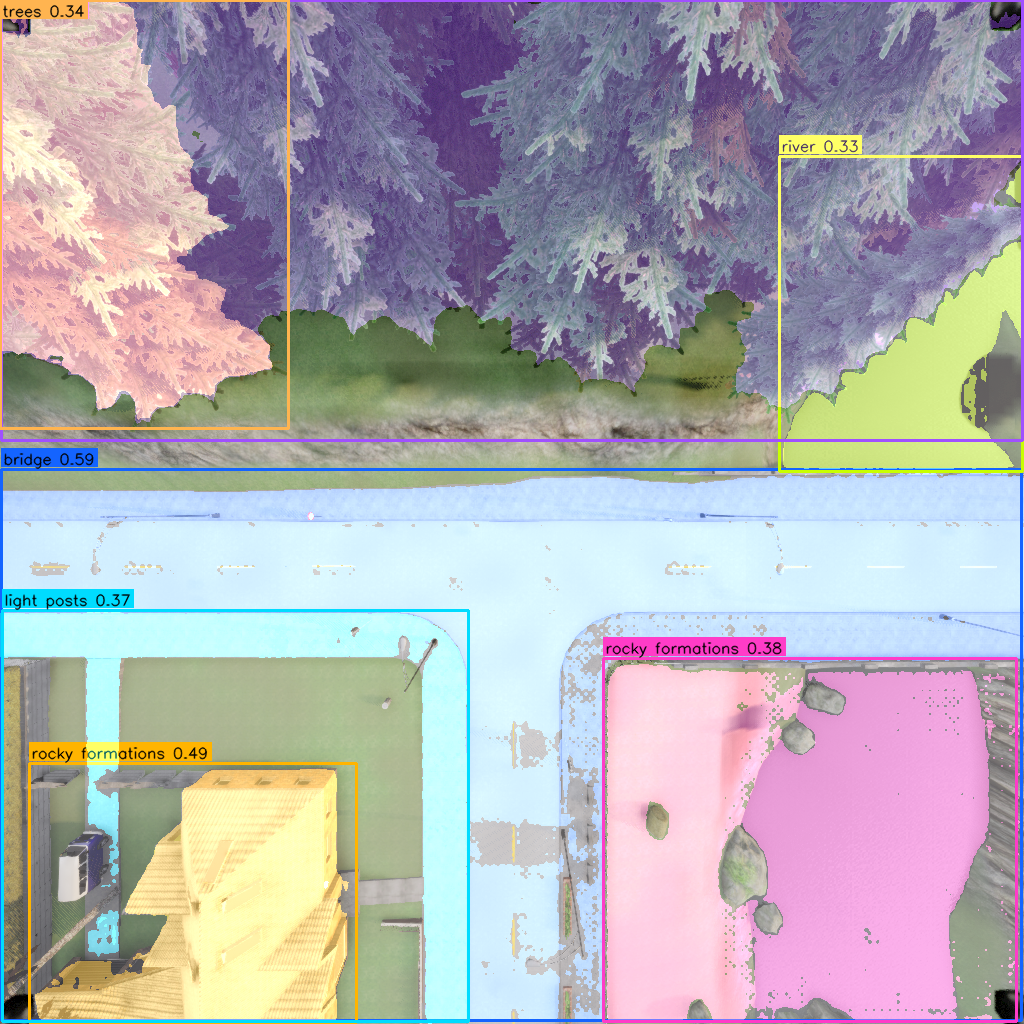

In [9]:
from IPython.display import Image, display

vis_path = SINGLE_OUTPUT_DIR / f"{IMAGE_PATH.stem}_vis.png"
display(Image(filename=str(vis_path)))
